In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('House_Rent_Dataset.csv')
data

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


In [3]:
data.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='str')

In [6]:
print("The Average Rent is",round(data['Rent'].mean()))
print("The Median Rent is",round(data['Rent'].median()))
print("The Highest Rent is",round(data['Rent'].max()))
print("The Minimum Rent is",round(data['Rent'].min()))

The Average Rent is 34993
The Median Rent is 16000
The Highest Rent is 3500000
The Minimum Rent is 1200


In [8]:
print(data[['City','Area Locality','BHK','Rent']].sort_values(by='Rent',ascending=False).head(10))

           City             Area Locality  BHK     Rent
1837  Bangalore              Marathahalli    3  3500000
1001     Mumbai                      Juhu    4  1200000
827      Mumbai     Raheja Artesia, Worli    4  1000000
1329     Mumbai              Breach Candy    4   850000
1459     Mumbai   Lady Ratan Tower, Worli    4   700000
1484     Mumbai                 Khar West    4   680000
1319     Mumbai                 Khar West    5   650000
1384     Mumbai               Bandra West    5   600000
726      Mumbai  Mount Marry, Bandra West    4   600000
3656    Chennai              Vettuvankeni    2   600000


In [9]:
print(data[['City','Area Locality','BHK','Rent']].sort_values(by='Rent',ascending=True).head(10))

           City       Area Locality  BHK  Rent
4076  Hyderabad       Uppal, NH 2 2    3  1200
285     Kolkata          Santoshpur    1  1500
471     Kolkata         Shyam Bazar    1  1800
2475      Delhi           Ram Nagar    2  2000
146     Kolkata      Behala silpara    2  2200
506     Kolkata           Baranagar    1  2200
4220  Hyderabad  Rhoda Mistri Nagar    1  3000
3068    Chennai              Ennore    1  3000
306     Kolkata             Hatiara    1  3000
3378    Chennai             Mangadu    1  3000


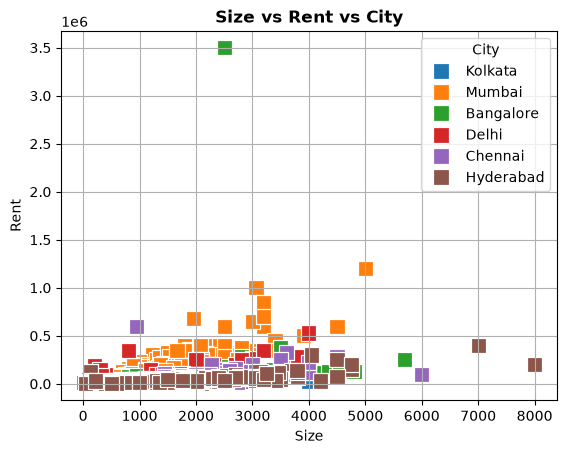

In [10]:
sns.scatterplot(data=data, x='Size', y='Rent', hue='City', s=120, marker='s')
plt.title('Size vs Rent vs City', fontweight='bold')
plt.grid(True)
plt.show()

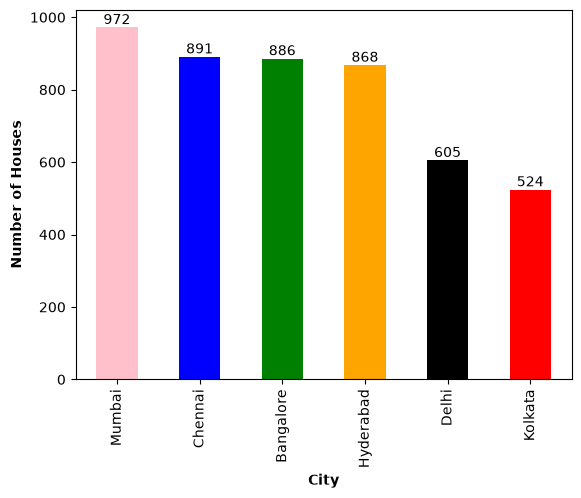

In [11]:
No_of_house=data['City'].value_counts()
colors = ['pink', 'blue', 'green', 'orange', 'Black','Red']
func=No_of_house.plot(kind='bar',color=colors)
for p in func.patches:
    func.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.xlabel('City',fontweight='bold')
plt.ylabel('Number of Houses',fontweight='bold')
plt.show()

In [12]:
grouped=data.groupby('Tenant Preferred')
population_sum = grouped['Furnishing Status'].value_counts()
print(population_sum)

Tenant Preferred  Furnishing Status
Bachelors         Unfurnished           409
                  Semi-Furnished        324
                  Furnished              97
Bachelors/Family  Semi-Furnished       1675
                  Unfurnished          1261
                  Furnished             508
Family            Semi-Furnished        252
                  Unfurnished           145
                  Furnished              75
Name: count, dtype: int64


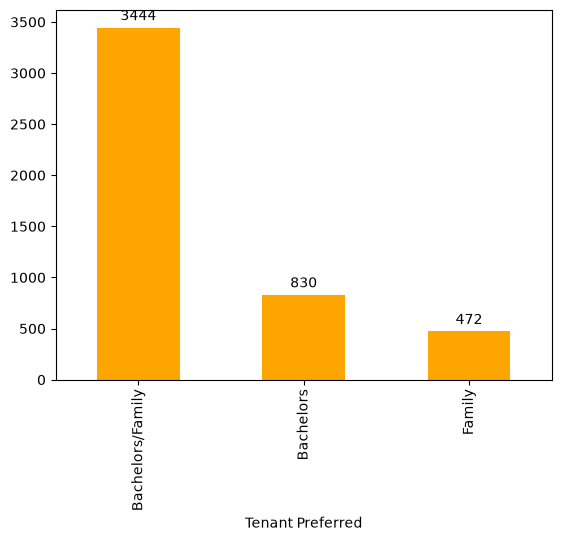

In [16]:
preffered=data['Tenant Preferred'].value_counts()
mac=preffered.plot(kind='bar',color='orange')
mac.bar_label(mac.containers[0], padding=3)
plt.show()

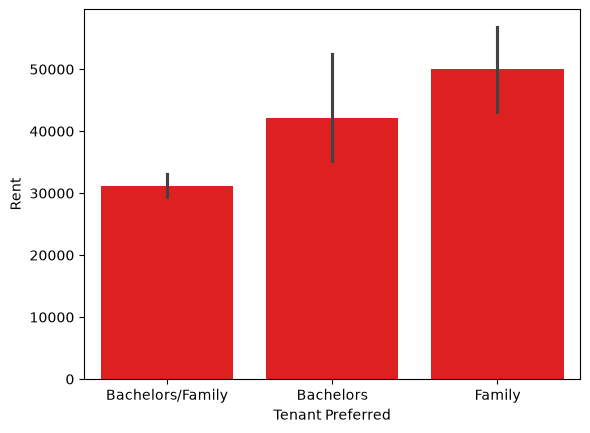

In [19]:
ab = sns.barplot(data=data,x='Tenant Preferred', y='Rent',color='red')
plt.show()

In [20]:
FS=data['Furnishing Status'].value_counts()
FS

Furnishing Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680
Name: count, dtype: int64

In [23]:
percentage_furnished = round((FS['Furnished'] / FS.sum()) * 100)
percentage_semi_furnished = round((FS['Semi-Furnished'] / FS.sum()) * 100)
percentage_unfurnished = round((FS['Unfurnished'] / FS.sum()) * 100)

X = [percentage_furnished, percentage_semi_furnished, percentage_unfurnished]
labels = ['Furnished','Semi-Furnished','Unfurnised']
print("Percentage of Furnished:", percentage_furnished, '%')
print("Percentage of Semi-Furnished:", percentage_semi_furnished, '%')
print("Percentage of Unfurnished:", percentage_unfurnished, '%')

Percentage of Furnished: 14 %
Percentage of Semi-Furnished: 47 %
Percentage of Unfurnished: 38 %


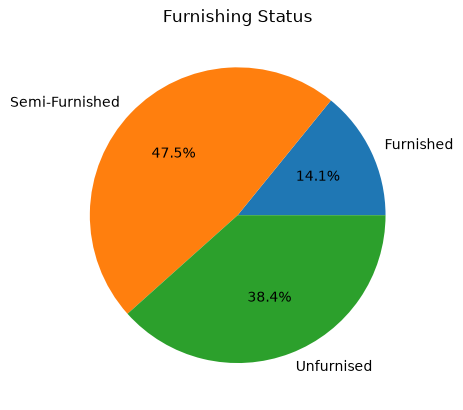

In [24]:
plt.pie(X,labels=labels,autopct='%1.1f%%')
plt.title('Furnishing Status')
plt.show()

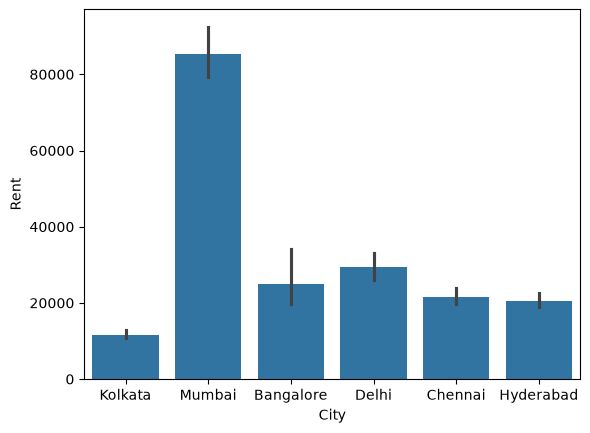

In [25]:
sns.barplot(data=data, x='City', y='Rent')
plt.show()

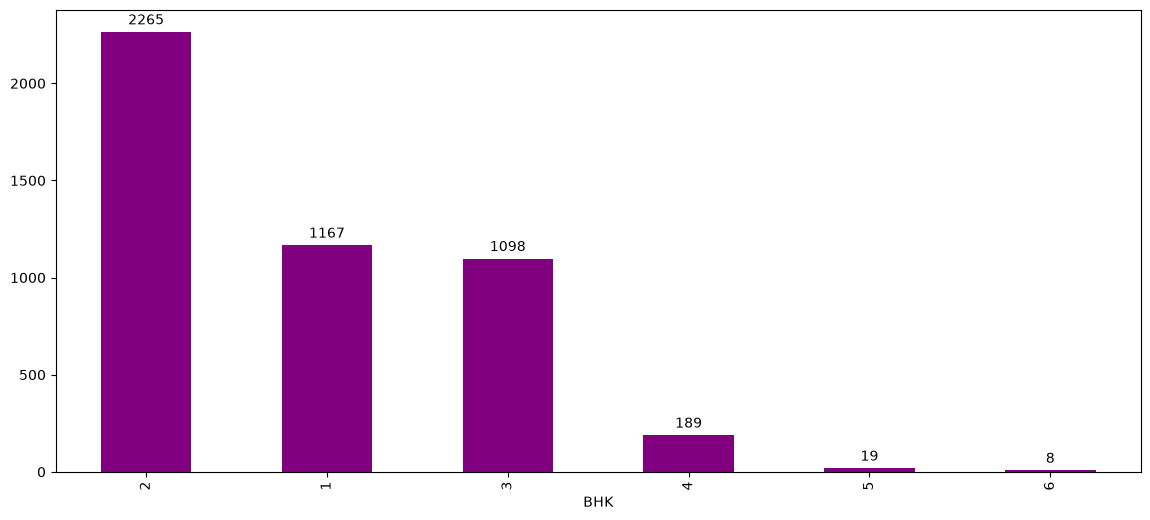

In [26]:
plt.figure(figsize=(14,6))
Bhk=data['BHK'].value_counts().plot(kind='bar',color='purple')
Bhk.bar_label(Bhk.containers[0], padding=3)
plt.show()

<Axes: >

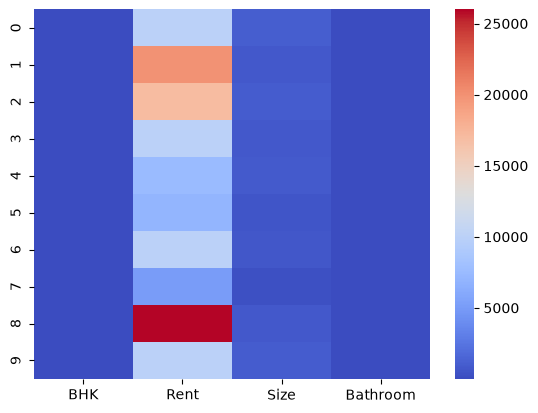

In [29]:
numberic=data.select_dtypes(include='number').head(10)
sns.heatmap(numberic,cmap='coolwarm')

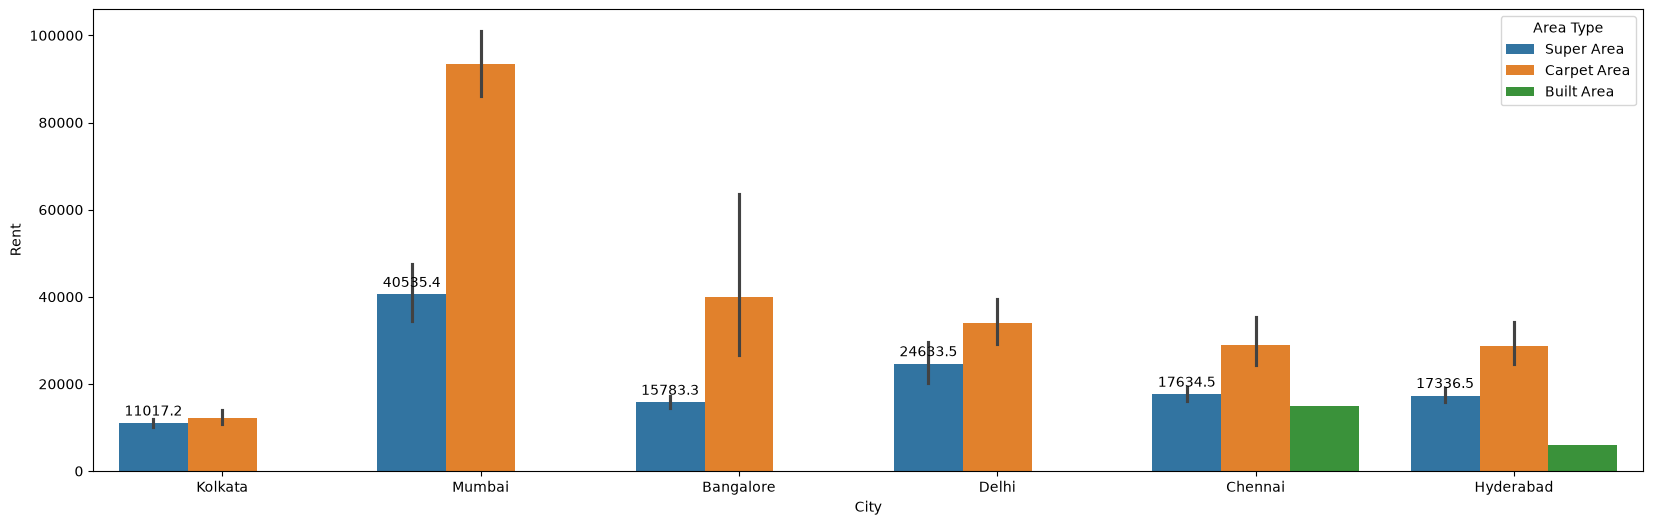

In [31]:
plt.figure(figsize=(20,6))
me=sns.barplot(data=data,x='City',y='Rent',hue='Area Type')
me.bar_label(me.containers[0],padding=3)
plt.show()